# Part 1 — Q3: Multi-Layer Perceptrons

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, roc_auc_score, classification_report)

In [27]:
# Load preprocessed data (from Q1 pipeline)
X_train_df = pd.read_parquet("data/X_train_scaled.parquet")
X_test_df  = pd.read_parquet("data/X_test_scaled.parquet")
y_train = pd.read_parquet("data/y_train.parquet").values.ravel()
y_test  = pd.read_parquet("data/y_test.parquet").values.ravel()

X_train = X_train_df.values
X_test  = X_test_df.values
feature_names = X_train_df.columns.tolist()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (734, 15), Test: (184, 15)


### Q3.1 — Implement a simple MLP, train it on the dataset, and report test set performance 

In [28]:
# MLP: two hidden layers (64, 32), ReLU activation, Adam optimiser
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)
mlp.fit(X_train, y_train)

y_pred  = mlp.predict(X_test)
y_proba = mlp.predict_proba(X_test)[:, 1]

print("MLP Test Set Performance")
print(f"  Accuracy          : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"  F1                : {f1_score(y_test, y_pred):.4f}")
print(f"  AUC-ROC           : {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

MLP Test Set Performance
  Accuracy          : 0.8478
  Balanced Accuracy : 0.8460
  F1                : 0.8627
  AUC-ROC           : 0.9222

               precision    recall  f1-score   support

   No Disease       0.83      0.83      0.83        82
Heart Disease       0.86      0.86      0.86       102

     accuracy                           0.85       184
    macro avg       0.85      0.85      0.85       184
 weighted avg       0.85      0.85      0.85       184



**Q3.1 Results.** The MLP (two hidden layers of size 64 and 32, ReLU activation, Adam optimiser with early stopping) achieves strong performance on the held-out test set:

| Metric | Value |
|---|---|
| Accuracy | 0.8478 |
| Balanced Accuracy | 0.8460 |
| F1 Score | 0.8627 |
| AUC-ROC | **0.9222** |

The AUC-ROC of 0.922 indicates excellent discriminative ability — the model correctly ranks a randomly chosen positive patient above a negative one in 92% of cases. Balanced accuracy (0.846) closely tracks overall accuracy (0.848), which confirms that the model does not simply exploit class imbalance. Both classes are handled roughly equally, with the Heart Disease class achieving slightly higher precision and recall (0.86 vs 0.83), likely because it is the slightly larger class (102 vs 82 test samples). Overall, the MLP outperforms the simpler models from Q1 and Q2 on most metrics, at the cost of interpretability.

### Q3.2 — Visualize SHAP explanations of the outputs of two positive and negative samples and feature importances of the overall model

To interpret the MLP's predictions we use **SHAP (SHapley Additive exPlanations)**, a post-hoc method grounded in cooperative game theory. SHAP assigns each feature a contribution value for a specific prediction: positive values push the output toward Heart Disease, negative values push it away. The contributions sum exactly to the difference between the model's prediction for that sample and the global baseline E[f(X)].

Because the MLP is a black-box model, we use **KernelExplainer**, a model-agnostic SHAP variant that estimates Shapley values by evaluating the model on coalitions of features against a background dataset (100 randomly sampled training points). This is computationally expensive but applicable to any classifier.

**Waterfall plots** (below) show the per-sample breakdown for two Heart Disease (positive) and two No Disease (negative) patients. The first positive sample is shown as an animated build-up to highlight how contributions accumulate from the baseline to the final prediction. **Summary plots** (beeswarm and bar) aggregate SHAP values over the entire test set to reveal global feature importance.

In [29]:
# KernelExplainer works with any model via predict_proba
# Use a small background sample to keep computation fast
background = shap.sample(X_train_df, 100, random_state=42)
explainer = shap.KernelExplainer(mlp.predict_proba, background)

# Compute SHAP values for the entire test set
# Result shape: (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_test_df, silent=True)
# Select class 1 (Heart Disease): [:, :, 1] → shape (n_samples, n_features)
shap_vals_pos = shap_values[:, :, 1]
print(f"SHAP values shape: {shap_vals_pos.shape}, features: {len(feature_names)}")

SHAP values shape: (184, 15), features: 15


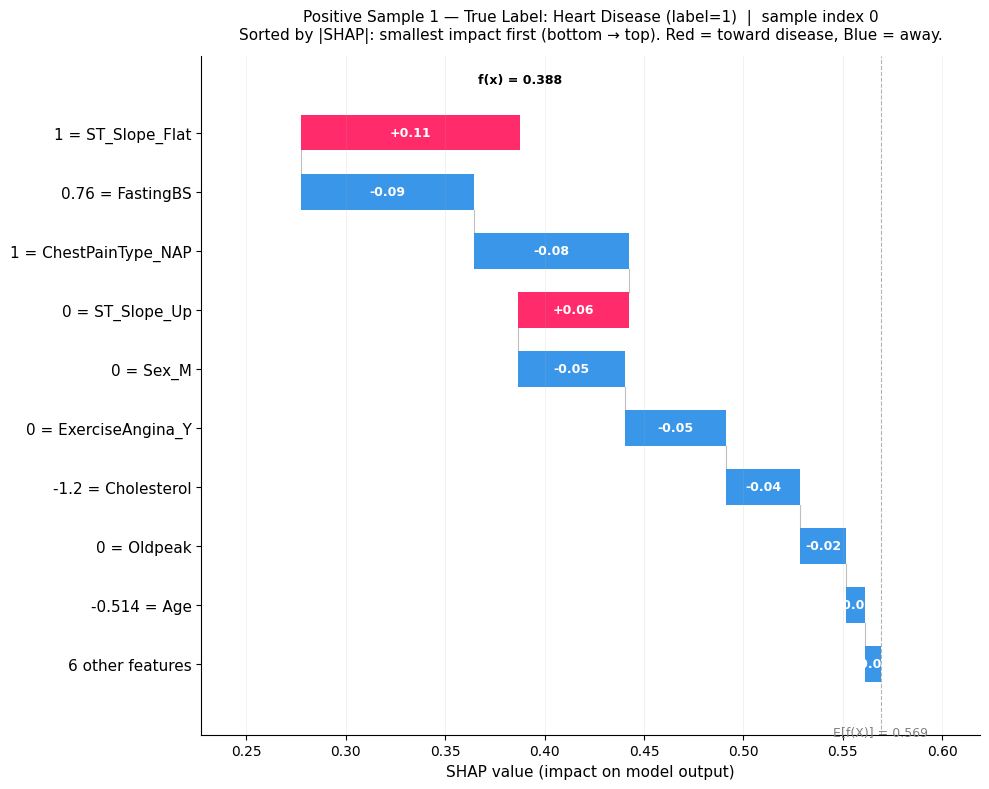

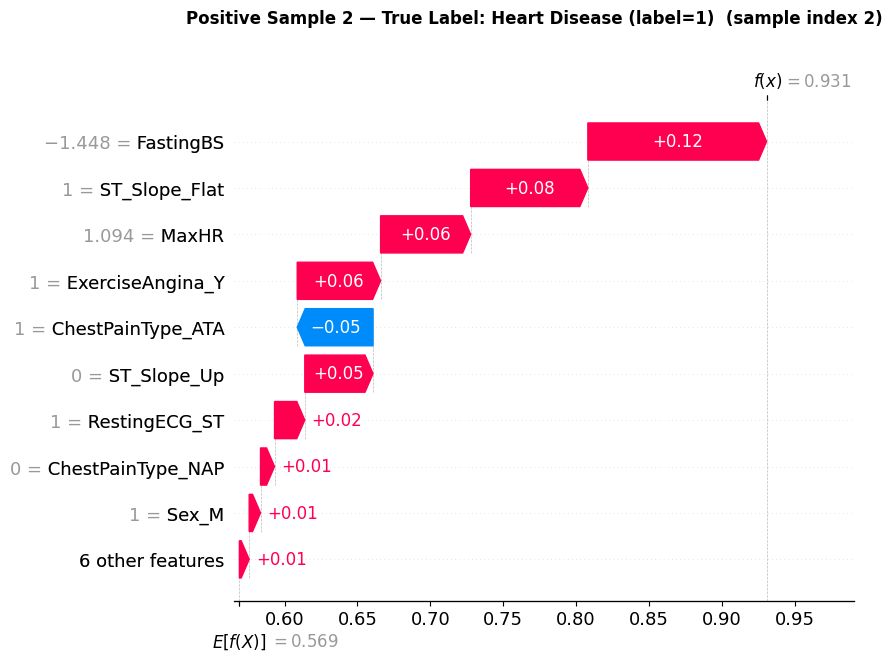

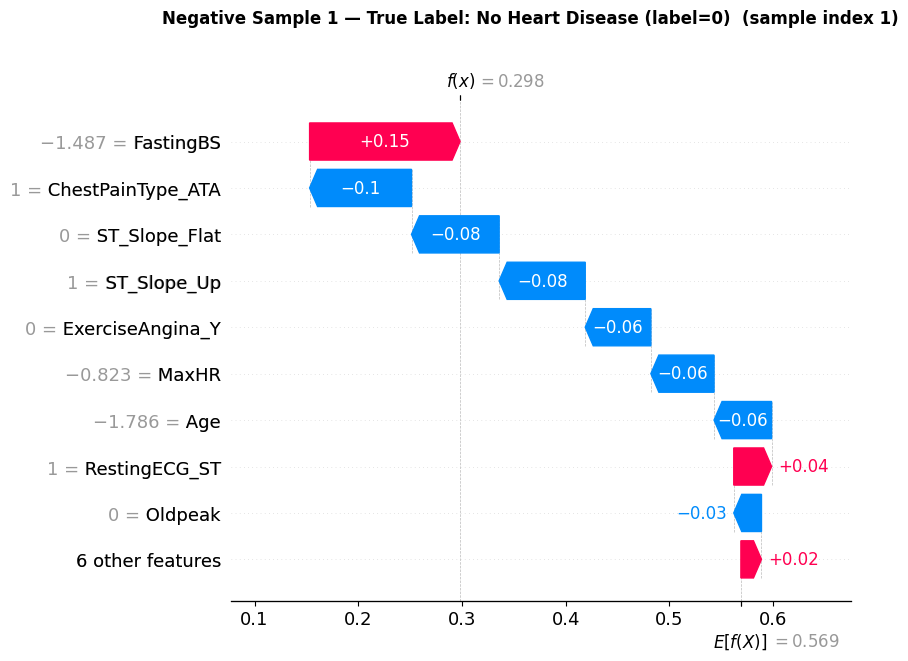

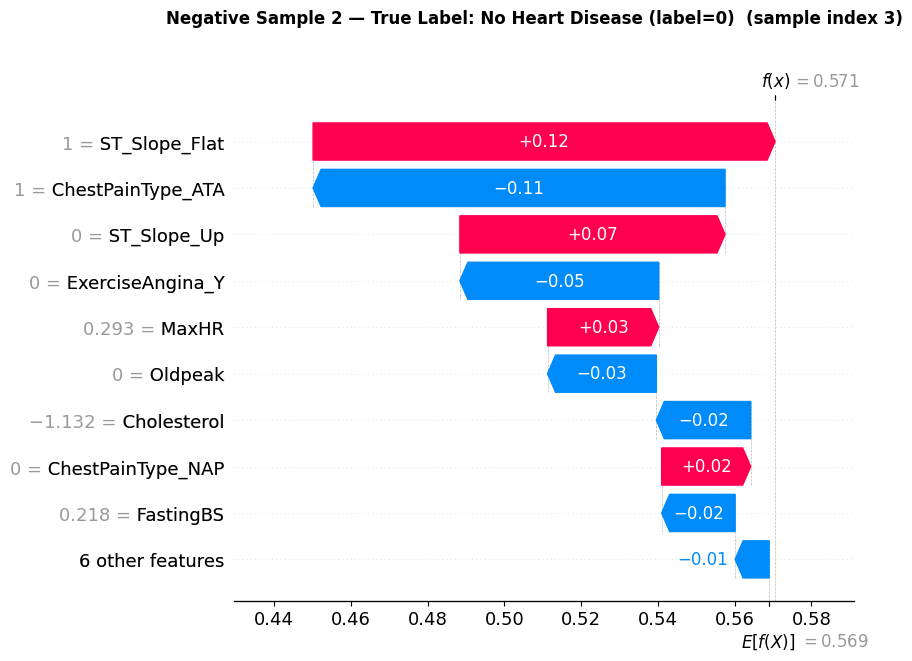

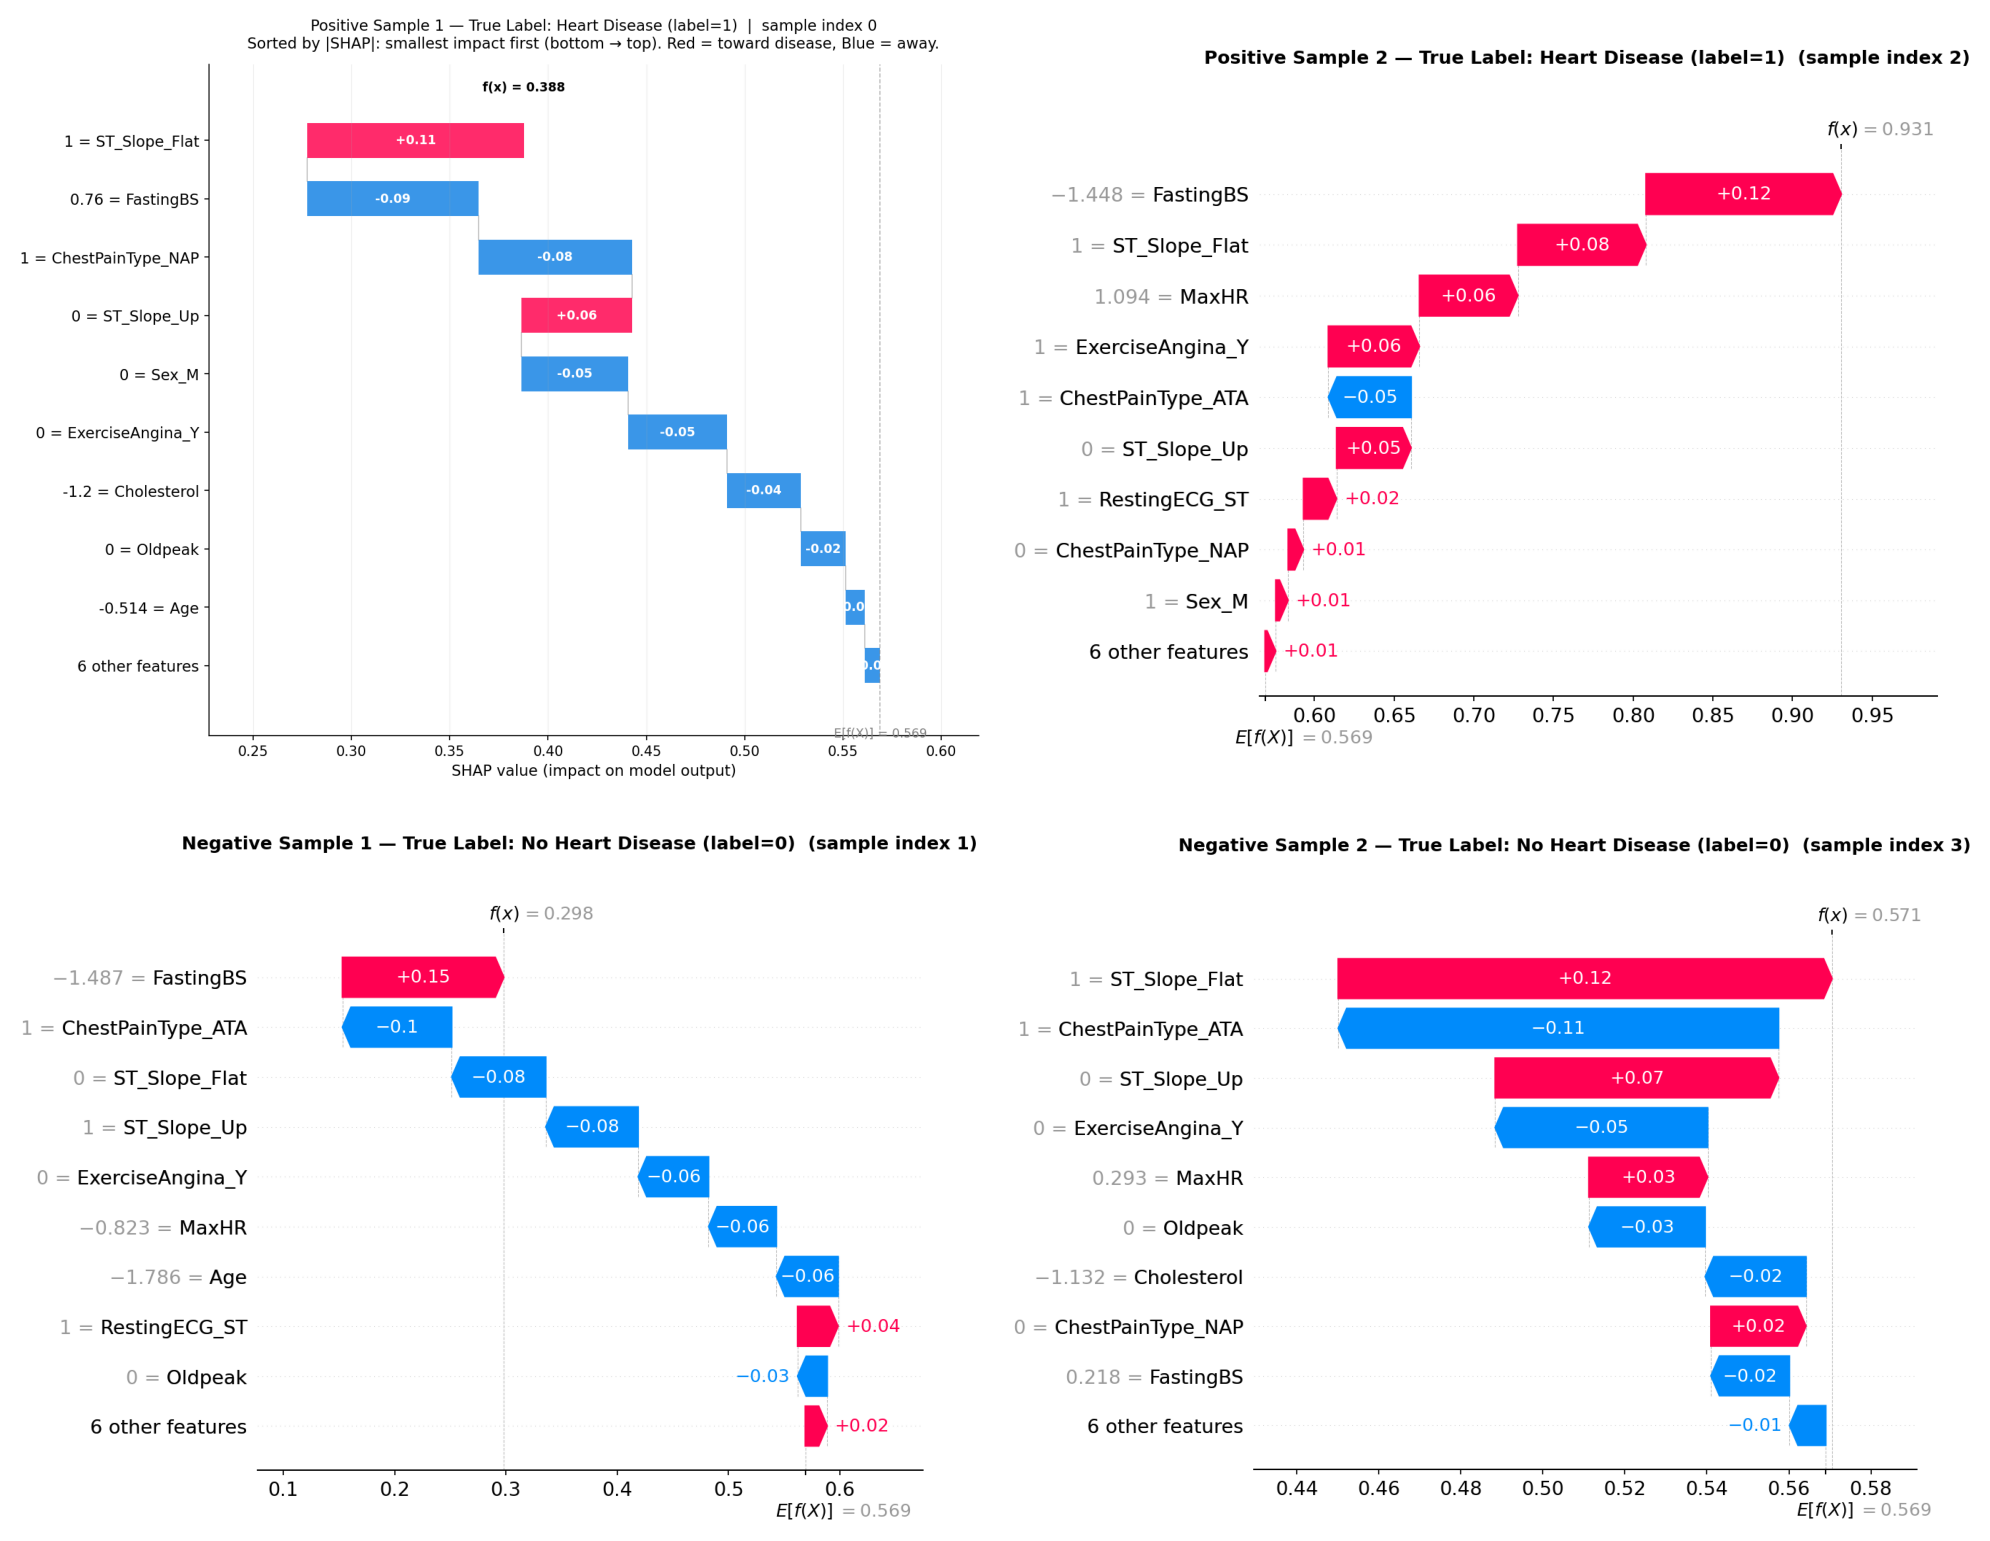

Saved → figures/waterfall_plots.png


In [8]:
import os
from IPython.display import clear_output, display as ipy_display
import matplotlib.image as mpimg
import time

os.makedirs('figures', exist_ok=True)

def _prep_waterfall_data(idx, shap_vals, base_value, X_df, feat_names, max_display=10):
    vals = shap_vals[idx]
    data_vals = X_df.iloc[idx].values.astype(float)
    n = len(vals)
    order = np.argsort(np.abs(vals))[::-1]
    if n > max_display:
        top = order[:max_display - 1]
        rest = order[max_display - 1:]
        sv = np.append(vals[top], vals[rest].sum())
        bar_names = [feat_names[i] for i in top] + [f"{len(rest)} other features"]
        bar_data = np.append(data_vals[top], np.nan)
    else:
        sv = vals[order].copy()
        bar_names = [feat_names[i] for i in order]
        bar_data = data_vals[order].copy()
    sv, bar_names, bar_data = sv[::-1], list(reversed(bar_names)), bar_data[::-1]
    y_labels = [
        bar_names[i] if np.isnan(bar_data[i]) else f"{bar_data[i]:.3g} = {bar_names[i]}"
        for i in range(len(sv))
    ]
    bases, running = [], base_value
    for v in sv:
        bases.append(running)
        running += v
    return dict(sv=sv, y_labels=y_labels, bases=bases,
                colors=['#FF0D57' if v >= 0 else '#1E88E5' for v in sv],
                final_pred=running)


def animated_waterfall(idx, title, shap_vals, base_value, X_df, feat_names,
                       max_display=10, n_steps=8, delay=0.01, save_path=None):
    d = _prep_waterfall_data(idx, shap_vals, base_value, X_df, feat_names, max_display)
    sv, bases, colors, y_labels, final_pred = d['sv'], d['bases'], d['colors'], d['y_labels'], d['final_pred']
    num_bars = len(sv)

    plt.ioff()
    fig, ax = plt.subplots(figsize=(10, max(4, num_bars * 0.55 + 2.5)))
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    all_x = bases + [b + v for b, v in zip(bases, sv)]
    ax.set_xlim(min(all_x) - 0.05, max(all_x) + 0.05)
    ax.set_ylim(-1.2, num_bars + 0.3)
    ax.set_yticks(np.arange(num_bars))
    ax.set_yticklabels(y_labels, fontsize=11)
    ax.set_xlabel("SHAP value (impact on model output)", fontsize=11)
    ax.set_title(f"{title}\nSorted by |SHAP|: smallest impact first (bottom → top). Red = toward disease, Blue = away.", fontsize=11, pad=12)
    ax.axvline(base_value, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(base_value, -1.05, f"E[f(X)] = {base_value:.3f}", ha='center', va='top', fontsize=9, color='gray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.25, linewidth=0.5)
    fig.tight_layout()

    for i in range(num_bars):
        bar_c = ax.barh(i, 0, left=bases[i], height=0.6, color=colors[i], alpha=0.88)
        rect = bar_c.patches[0]
        for step in range(1, n_steps + 1):
            t = step / n_steps
            partial = sv[i] * t
            if sv[i] >= 0:
                rect.set_x(bases[i])
                rect.set_width(partial)
            else:
                rect.set_x(bases[i] + partial)
                rect.set_width(-partial)
            clear_output(wait=True)
            ipy_display(fig)
            time.sleep(delay)
        ax.text(bases[i] + sv[i] / 2, i, f"{'+' if sv[i] >= 0 else ''}{sv[i]:.2f}",
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        if i < num_bars - 1:
            ax.plot([bases[i] + sv[i], bases[i] + sv[i]], [i + 0.3, i + 0.7],
                    color='gray', linewidth=0.8, alpha=0.5)

    ax.text(final_pred, num_bars - 0.2, f"f(x) = {final_pred:.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)

    clear_output(wait=True)
    ipy_display(fig)
    plt.close(fig)
    plt.ion()


pos_idx = np.where(y_test == 1)[0][:2]
neg_idx = np.where(y_test == 0)[0][:2]
base_val = explainer.expected_value[1]

# First sample: animated, saved to figures/waterfall_0.png
animated_waterfall(
    pos_idx[0],
    f"Positive Sample 1 — True Label: Heart Disease (label=1)  |  sample index {pos_idx[0]}",
    shap_vals_pos, base_val, X_test_df, feature_names,
    save_path='figures/waterfall_0.png',
)

# Remaining 3 samples: SHAP waterfall with suptitle indicating positive/negative
plot_specs = [
    (pos_idx[1], "Positive Sample 2 — True Label: Heart Disease (label=1)"),
    (neg_idx[0], "Negative Sample 1 — True Label: No Heart Disease (label=0)"),
    (neg_idx[1], "Negative Sample 2 — True Label: No Heart Disease (label=0)"),
]
save_paths = ['figures/waterfall_0.png']

for i, (idx, label) in enumerate(plot_specs):
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals_pos[idx],
            base_values=base_val,
            data=X_test_df.iloc[idx].values,
            feature_names=feature_names,
        ),
        show=False,
    )
    plt.gcf().suptitle(f"{label}  (sample index {idx})", fontsize=12, fontweight='bold', y=1.02)
    path = f'figures/waterfall_{i + 1}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()
    save_paths.append(path)

# Combine all 4 into a 2×2 grid → figures/waterfall_plots.png
# Titles are already embedded in each saved PNG, so no ax.set_title needed
fig_grid, axes = plt.subplots(2, 2, figsize=(20, 16))
for ax, path in zip(axes.flatten(), save_paths):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.savefig('figures/waterfall_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/waterfall_plots.png")

Global feature importance (beeswarm plot)


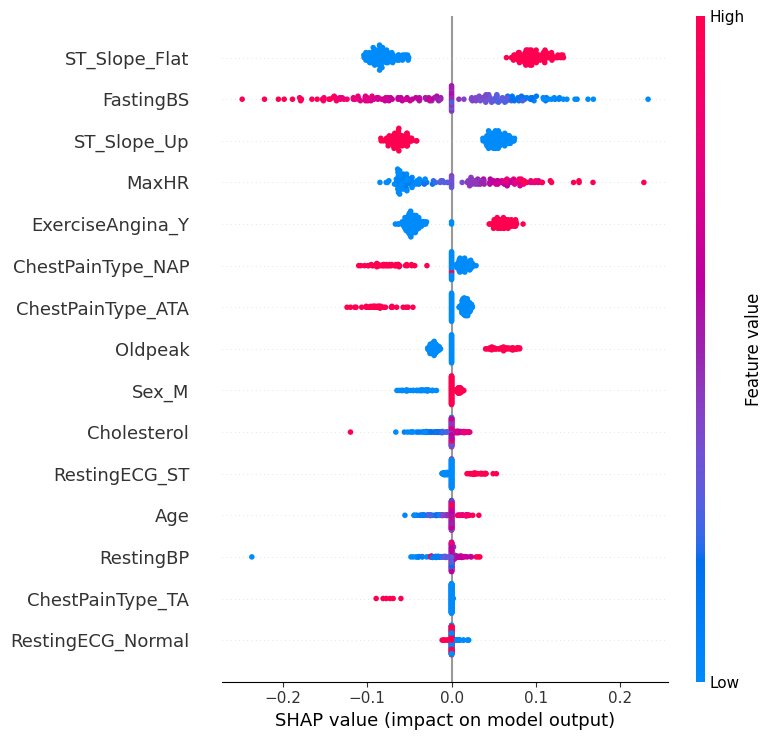

Saved → figures/beeswarm.png
Mean absolute SHAP values per feature


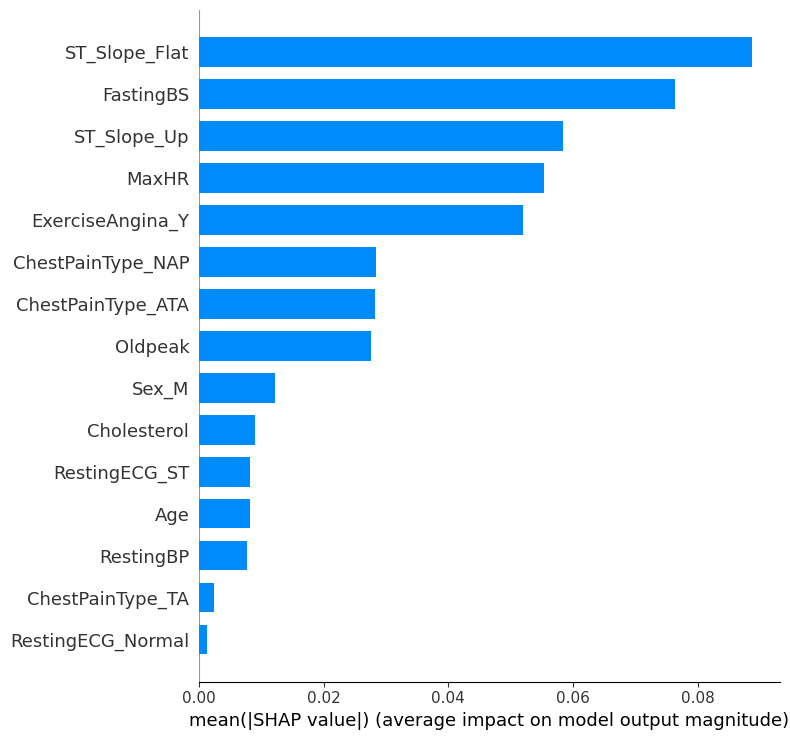

In [31]:
# Beeswarm plot — saved to figures/beeswarm.png
print("Global feature importance (beeswarm plot)")
shap.summary_plot(shap_vals_pos, X_test_df, feature_names=feature_names, show=False)
plt.savefig('figures/beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → figures/beeswarm.png")

# Bar plot of mean |SHAP| per feature
print("Mean absolute SHAP values per feature")
shap.summary_plot(shap_vals_pos, X_test_df, feature_names=feature_names,
                  plot_type="bar", show=True)

**Q3.2 Observations.**

*Waterfall plots (individual predictions):* Each bar shows how much a feature shifts the prediction away from the baseline E[f(X)] ≈ 0.569. For the first positive sample (Heart Disease=1), `ST_Slope_Flat=1` is the strongest driver toward disease (+0.11), while several features such as `ChestPainType_NAP` and `FastingBS` push the prediction downward — resulting in a final prediction of 0.388, lower than the baseline despite the true label being 1. This illustrates a case where the model underestimates risk. For negative samples, the contributions are predominantly blue (pushing away from disease), consistent with the true label.

*Beeswarm plot (global importance):* The features are ranked by mean |SHAP value| across all 184 test patients. The top globally important features are:

1. **ST_Slope_Flat** — flat ST slope is a strong marker of disease (red dots = high value = large positive SHAP)
2. **FastingBS** — high fasting blood sugar increases predicted risk
3. **ST_Slope_Up** — upward ST slope is protective (red dots have strongly negative SHAP, i.e., push away from disease)
4. **MaxHR** — higher maximum heart rate is associated with lower disease risk (red = high HR = negative SHAP)
5. **ExerciseAngina_Y** — presence of exercise-induced angina increases predicted risk

Features at the bottom (`RestingBP`, `Age`, `RestingECG_Normal`) show dots clustered near zero, indicating the MLP has learned to rely on them very little for this dataset.

The ST segment is the flat section of the ECG waveform between the end of the S wave and the start of the T wave. Its shape during an exercise stress test is a key diagnostic marker for coronary artery disease:

- **Flat (ST_Slope_Flat)** — horizontal ST segment; associated with reduced blood flow to the heart and a strong indicator of disease
- **Up (ST_Slope_Up)** — upward-sloping ST segment; a normal, healthy response during exercise
- **Down** — downward slope; also abnormal (the reference category in this one-hot encoding)

This clinical meaning explains why `ST_Slope_Flat` and `ST_Slope_Up` are the top two globally important features: they directly reflect the heart's response to stress and are well-established predictors of coronary artery disease.

### Q3.3 — Are feature importances consistent across different predictions and compared to overall importance values?

Feature importances are partially consistent, but with notable sample-level variation.

**Consistency between local and global importance.**
The top globally important features (e.g., `ST_Slope_Flat`, `ST_Slope_Up`, `MaxHR`, `ExerciseAngina_Y`) also appear as dominant contributors in the individual waterfall plots. This indicates that the MLP has learned stable, clinically meaningful patterns: features that matter on average tend to appear prominently in individual explanations too. This is reassuring from a reliability standpoint.

**Direction is globally consistent.**
The beeswarm plot shows a clear color structure. For most features, high values (red) consistently push in one direction across all patients. For example, `ST_Slope_Flat=1` almost always increases predicted risk (positive SHAP), and `ST_Slope_Up=1` almost always decreases it. This directional consistency mirrors the known clinical literature and suggests the model has learned interpretable associations.

**Magnitude varies substantially across samples.**
While direction is consistent, the *size* of contributions differs considerably from patient to patient. A feature that contributes +0.11 for one patient may contribute near zero for another with a different clinical profile. We expect this from a non-linear model as the MLP captures interaction effects, so the influence of one feature depends on the values of others. This is in contrast to a linear model (e.g., Lasso from Q2), where feature weights are fixed and the contribution scales linearly with the feature value.

**Some globally unimportant features dominate individual predictions.**
In some waterfall plots, features with low global importance (near the bottom of the beeswarm) appear with non-negligible contributions for a specific patient. This is consistent with the non-linear nature of MLPs, which can activate feature interactions that are rare but strong in specific corners of the input space.




**Conclusion:**
Feature importances show *moderate global consistency*: the ranking of the most important features is stable, and directions are clinically plausible. However, the magnitude and relative ranking of contributions are sample-specific, reflecting the non-linear, interaction-driven representations learned by the MLP. This makes MLPs harder to interpret globally than linear models.